In [71]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Land_Reg/transaction_dataset.csv')

df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [50]:
df.shape

(9841, 51)

In [13]:
df.columns

Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 

In [52]:
columns_to_drop = ['Address', ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx',
       ' ERC20 avg time between rec 2 tnx',
       ' ERC20 avg time between contract tnx', ' ERC20 min val rec',
       ' ERC20 max val rec', ' ERC20 avg val rec', ' ERC20 min val sent',
       ' ERC20 max val sent', ' ERC20 avg val sent',
       ' ERC20 min val sent contract', ' ERC20 max val sent contract',
       ' ERC20 avg val sent contract', ' ERC20 uniq sent token name',
       ' ERC20 uniq rec token name', ' ERC20 most sent token type',
       ' ERC20_most_rec_token_type','Unnamed: 0','Index',
       'Time Diff between first and last (Mins)',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent','total ether sent contracts']
df = df.drop(columns=columns_to_drop)
df.head()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Sent tnx,Received Tnx,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether balance
0,0,844.26,1093.71,721,89,0.0,0.0,0.0,810,865.691093,586.466675,-279.224419
1,0,12709.07,2958.44,94,8,0.0,0.0,0.0,102,3.087297,3.085478,-0.001819
2,0,246194.54,2434.02,2,10,0.0,0.0,0.0,12,3.588616,3.589057,0.000441
3,0,10219.60,15785.09,25,9,0.0,0.0,0.0,34,1750.045862,895.399559,-854.646303
4,0,36.61,10707.77,4598,20,0.0,0.0,0.0,4619,104.318883,53.421897,-50.896986


In [53]:
df.columns

Index(['FLAG', 'Avg min between sent tnx', 'Avg min between received tnx',
       'Sent tnx', 'Received Tnx', 'min value sent to contract',
       'max val sent to contract', 'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received', 'total ether balance'],
      dtype='object')

In [54]:
df = df.rename(columns={
    'FLAG': 'Flag',
    'Avg min between sent tnx': 'avg_Time_Between_Sent_Trans',
    'Avg min between received tnx': 'avg_Time Between_Receive_Trans',
    'Sent tnx': 'send_Trans',
    'Received Tnx': 'receive_Trans',
    'min value sent to contract': 'min_Value_Sent_to_Contract',
    'max val sent to contract': 'max_Value_Sent_to_Contract',
    'avg value sent to contract': 'avg_Value_Sent_to_Contract',
    'total transactions (including tnx to create contract': 'Total_Trans',

    'total Ether sent': 'Total_Ether_Sent',
    'total ether received': 'Total_Ether_Received',
    'total ether balance': 'Total_Ether_Balance',

})

df.columns

Index(['Flag', 'avg_Time_Between_Sent_Trans', 'avg_Time Between_Receive_Trans',
       'send_Trans', 'receive_Trans', 'min_Value_Sent_to_Contract',
       'max_Value_Sent_to_Contract', 'avg_Value_Sent_to_Contract',
       'Total_Trans', 'Total_Ether_Sent', 'Total_Ether_Received',
       'Total_Ether_Balance'],
      dtype='object')

In [55]:
df.shape

(9841, 12)

In [57]:
df.duplicated().sum()

1222

In [58]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [59]:
df.isnull().sum()

,0
Flag,0
avg_Time_Between_Sent_Trans,0
avg_Time Between_Receive_Trans,0
send_Trans,0
receive_Trans,0
min_Value_Sent_to_Contract,0
max_Value_Sent_to_Contract,0
avg_Value_Sent_to_Contract,0
Total_Trans,0
Total_Ether_Sent,0


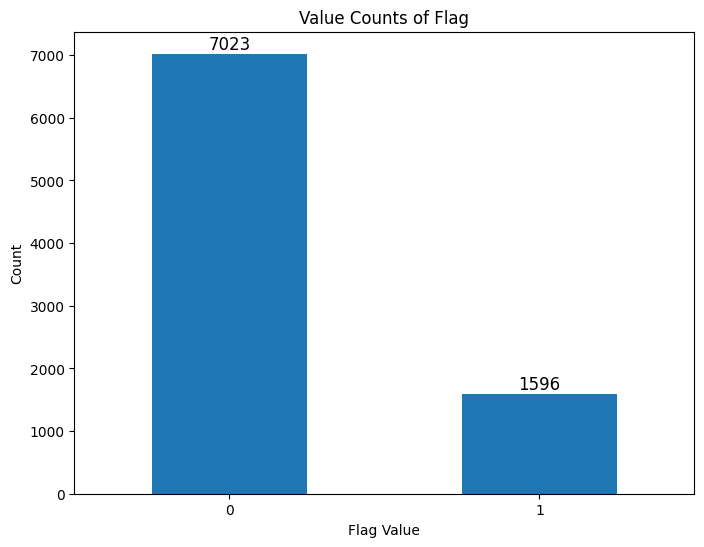

In [23]:
import matplotlib.pyplot as plt

flag_counts = df['Flag'].value_counts()

plt.figure(figsize=(8, 6))
ax = flag_counts.plot(kind='bar', rot=0)

for i, v in enumerate(flag_counts):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=12)

plt.xlabel('Flag Value')
plt.ylabel('Count')
plt.title('Value Counts of Flag')
plt.show()

In [60]:
from imblearn.over_sampling import SMOTE

X = df.drop('Flag', axis=1)
y = df['Flag']

# Applying SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

data = pd.concat([X_resampled, y_resampled], axis=1)

print(data['Flag'].value_counts())

Flag
0    7023
1    7023
Name: count, dtype: int64


In [63]:
# train test split

from sklearn.model_selection import train_test_split

X = data.drop('Flag', axis=1)
y = data['Flag']

# Identify columns with object (string) dtype if required
#object_cols = X.select_dtypes(include=['object']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [65]:
# saving scaling in pickle

import pickle

with open('/content/drive/MyDrive/Land_Reg/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [73]:
import xgboost as xgb

# Initialize the XGBoost classifier
#xgb_classifier = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_classifier = xgb.XGBClassifier(
    n_estimators=500,  # Increase the number of estimators
    max_depth=25,      # Increase the maximum depth of trees
    learning_rate=0.1,  # Adjust the learning rate
    subsample=0.8,     # Use a fraction of the training data for each tree
    colsample_bytree=0.8, # Use a fraction of the features for each tree
    random_state=42
)

# Train the classifier
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
accuracy

1.0

In [69]:
confusion_matrix(y_test, y_pred)

array([[1343,   96],
       [  80, 1291]])

In [70]:
# Save the trained model to a file
with open('/content/drive/MyDrive/Land_Reg/xgb_classifier_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)